In [2]:
from utils.utils import DataLoader
from utils.utils import plot_feature_per_label
import matplotlib.pyplot as plt
import numpy as np

#base_path = "../MyDB1"
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
exp_list = [f"NewExp{i}" for i in range(1, 51)]
to_load = ["labels"]
data_loader = DataLoader(base_path, exp_list=exp_list, to_load=to_load)

🔄 Loading data for NewExp1...
🔄 Loading data for NewExp2...
🔄 Loading data for NewExp3...
🔄 Loading data for NewExp4...
🔄 Loading data for NewExp5...
🔄 Loading data for NewExp6...
🔄 Loading data for NewExp7...
🔄 Loading data for NewExp8...
🔄 Loading data for NewExp9...
🔄 Loading data for NewExp10...
🔄 Loading data for NewExp11...
🔄 Loading data for NewExp12...
🔄 Loading data for NewExp13...
🔄 Loading data for NewExp14...
🔄 Loading data for NewExp15...
🔄 Loading data for NewExp16...
🔄 Loading data for NewExp17...
🔄 Loading data for NewExp18...
🔄 Loading data for NewExp19...
🔄 Loading data for NewExp20...
🔄 Loading data for NewExp21...
🔄 Loading data for NewExp22...
🔄 Loading data for NewExp23...
🔄 Loading data for NewExp24...
🔄 Loading data for NewExp25...
🔄 Loading data for NewExp26...
🔄 Loading data for NewExp27...
🔄 Loading data for NewExp28...
🔄 Loading data for NewExp29...
🔄 Loading data for NewExp30...
🔄 Loading data for NewExp31...
🔄 Loading data for NewExp32...
🔄 Loading data fo

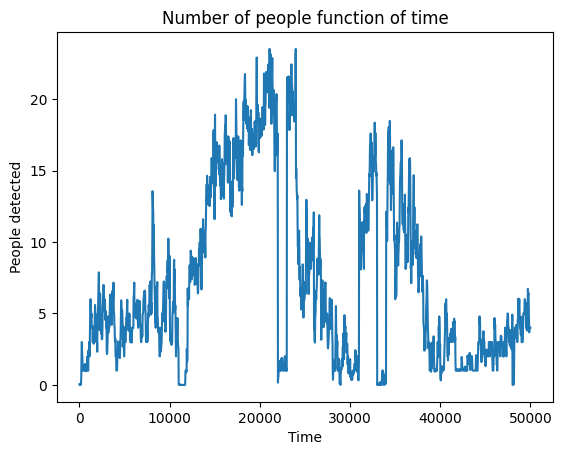

In [15]:
# Make a graph of labels function of time (group by mean of 250 labels)
groups_size = 25
labels = data_loader.get_labels()
labels = labels.reshape(-1, groups_size, 1)
labels = np.mean(labels, axis=1)
labels = labels.squeeze()

time = np.linspace(0, groups_size*len(labels), len(labels))

plt.plot(time, labels)
plt.xlabel("Time")
plt.ylabel("People detected")
plt.title("Number of people function of time")
plt.show()

/var/folders/wd/22m2pstj38z_7_gc5syv9fgr0000gn/T/ipykernel_6373/1694725318.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # pour laisser de la place à la colorbar


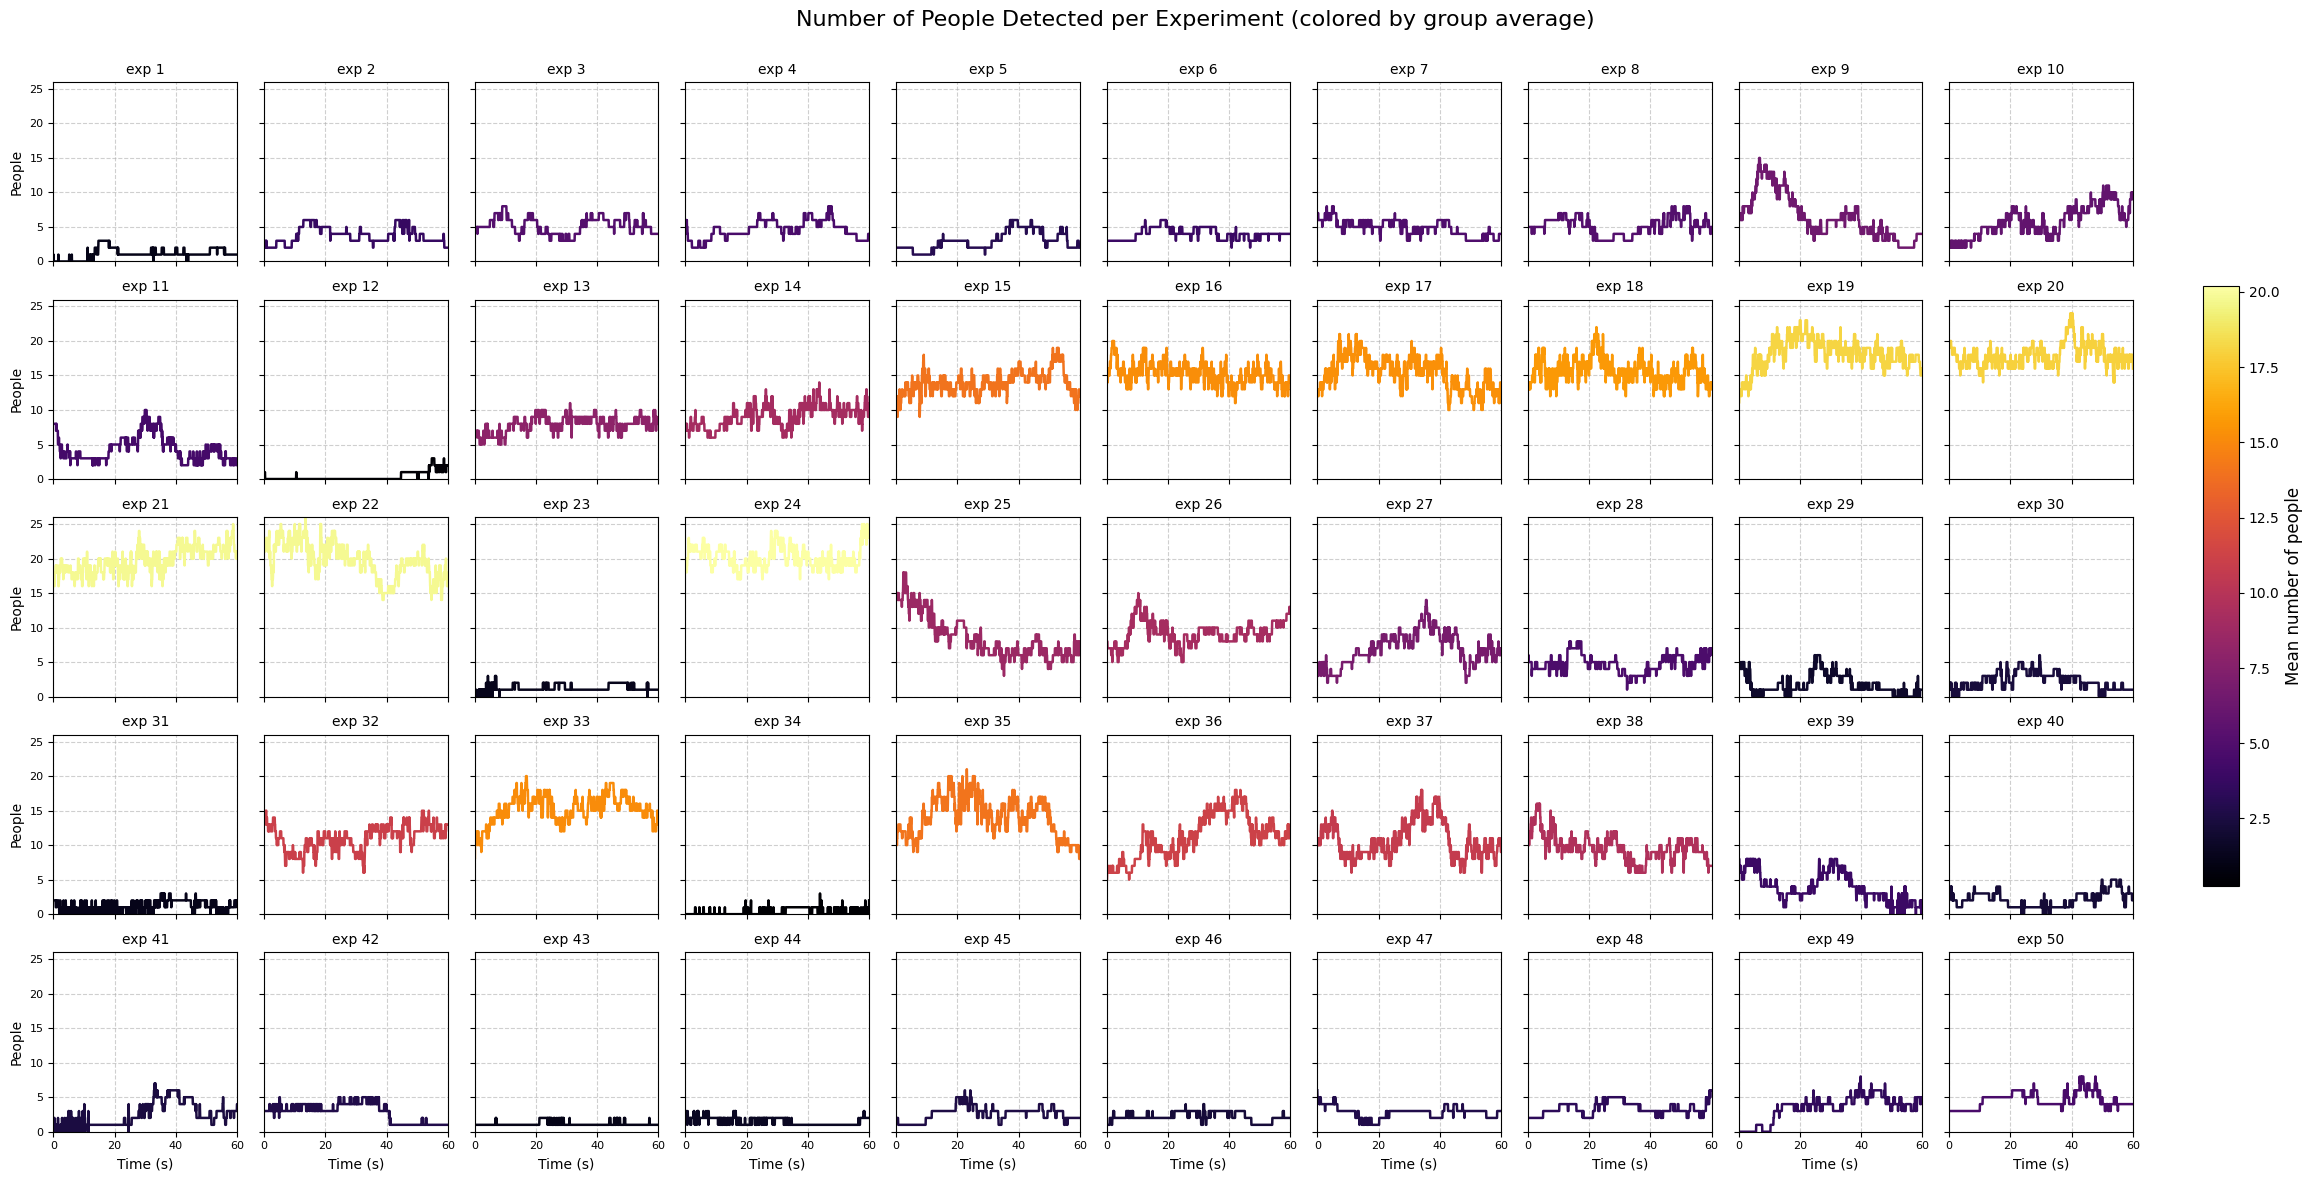

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

# Paramètres
groups_size = 1000
num_experiments = 50  # 10x5 grid
n_rows, n_cols = 5, 10
duration_sec = 60

# Chargement des labels
labels = data_loader.get_labels()

# Temps exprimé en secondes
time = np.linspace(0, duration_sec, groups_size)

# Préparation des moyennes de personnes pour chaque expérience
group_means = [np.mean(labels[i * groups_size:(i + 1) * groups_size]) for i in range(num_experiments)]

# Normalisation pour la colormap
norm = colors.Normalize(vmin=min(group_means), vmax=max(group_means))
cmap = cm.inferno  # Tu peux aussi tester: cm.plasma, cm.inferno, cm.cividis, etc.
scalar_map = cm.ScalarMappable(norm=norm, cmap=cmap)

# Création de la figure
fig, axs = plt.subplots(n_rows, n_cols, figsize=(24, 12), sharex=True, sharey=True)
axs = axs.flatten()

# Échelle Y uniforme
ymin = np.min(labels)
ymax = np.max(labels)

for idx in range(num_experiments):
    group_start = idx * groups_size
    group_end = group_start + groups_size

    if group_end > len(labels):
        continue

    group_labels = labels[group_start:group_end]
    color = scalar_map.to_rgba(group_means[idx])

    axs[idx].plot(time, group_labels, color=color, linewidth=1.8)
    axs[idx].set_title(f'exp {idx+1}', fontsize=10)
    axs[idx].grid(True, linestyle='--', alpha=0.6)
    axs[idx].set_ylim(ymin, ymax)
    axs[idx].set_xlim(0, duration_sec)
    axs[idx].tick_params(axis='both', labelsize=8)

# Étiquettes des axes sur les bords
for i in range(n_rows):
    axs[i * n_cols].set_ylabel("People", fontsize=10)
for j in range(n_cols):
    axs[(n_rows - 1) * n_cols + j].set_xlabel("Time (s)", fontsize=10)

# Ajout d'une colorbar en tant que légende
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(scalar_map, cax=cbar_ax)
cbar.set_label('Mean number of people', fontsize=12)

# Mise en page finale
plt.tight_layout(rect=[0, 0, 0.9, 1])  # pour laisser de la place à la colorbar
plt.subplots_adjust(top=0.92)
fig.suptitle("Number of People Detected per Experiment (colored by group average)", fontsize=16)

plt.show()


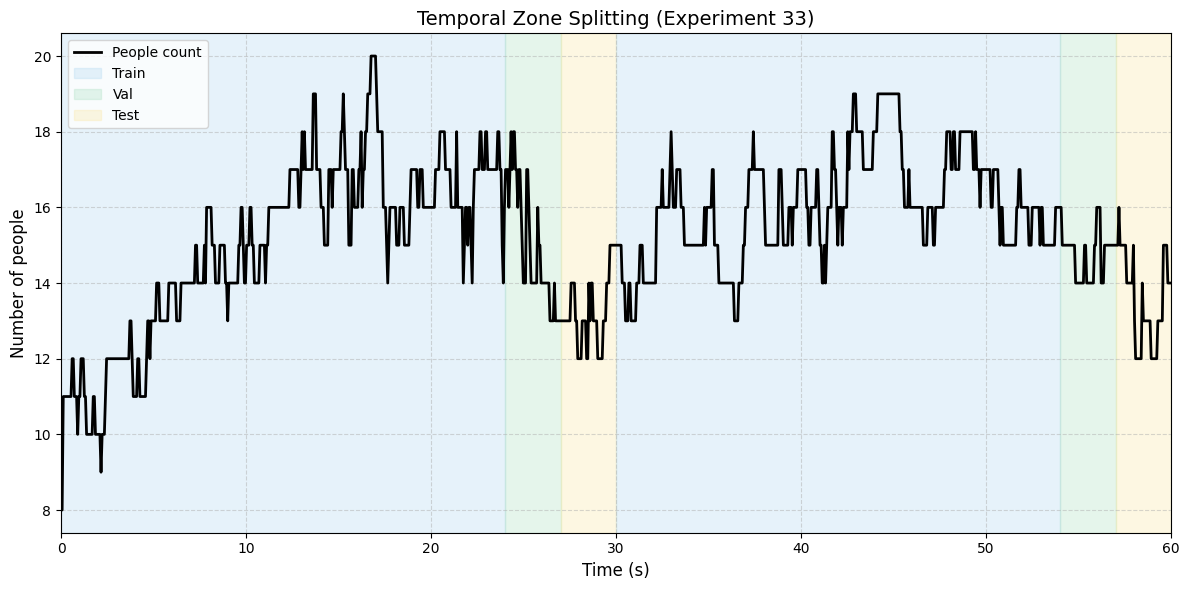

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres
groups_size = 1000
duration_sec = 60

# Chargement des labels
labels = data_loader.get_labels()

# Sélection de l'expérience 33 (index 32 en Python)
exp_id = 32
group_start = exp_id * groups_size
group_end = group_start + groups_size
group_labels = labels[group_start:group_end]

# Temps en secondes
time = np.linspace(0, duration_sec, groups_size)

# Découpage 2 cycles (Train/Val/Test) : 80% / 10% / 10% de chaque cycle (cycle = 30s)
cycle_duration = duration_sec / 2
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

# Bornes des zones
zone_starts = [0,
               train_ratio * cycle_duration,
               (train_ratio + val_ratio) * cycle_duration,
               cycle_duration,
               cycle_duration + 0,
               cycle_duration + train_ratio * cycle_duration,
               cycle_duration + (train_ratio + val_ratio) * cycle_duration,
               duration_sec]

# Couleurs et noms des zones pour légende unique
zone_infos = [
    (zone_starts[0], zone_starts[1], 'Train', '#AED6F1'),
    (zone_starts[1], zone_starts[2], 'Val', '#A9DFBF'),
    (zone_starts[2], zone_starts[3], 'Test', '#F9E79F'),
    (zone_starts[4], zone_starts[5], 'Train', '#AED6F1'),
    (zone_starts[5], zone_starts[6], 'Val', '#A9DFBF'),
    (zone_starts[6], zone_starts[7], 'Test', '#F9E79F'),
]

# Tracé principal
plt.figure(figsize=(12, 6))
plt.plot(time, group_labels, color='black', linewidth=2, label='People count')

# Coloriage des zones avec légende unique
already_plotted = set()
for start, end, label, color in zone_infos:
    show_label = label if label not in already_plotted else None
    plt.axvspan(start, end, color=color, alpha=0.3, label=show_label)
    already_plotted.add(label)

# Mise en forme
plt.xlim(0, duration_sec)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Number of people', fontsize=12)
plt.title('Temporal Zone Splitting (Experiment 33)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


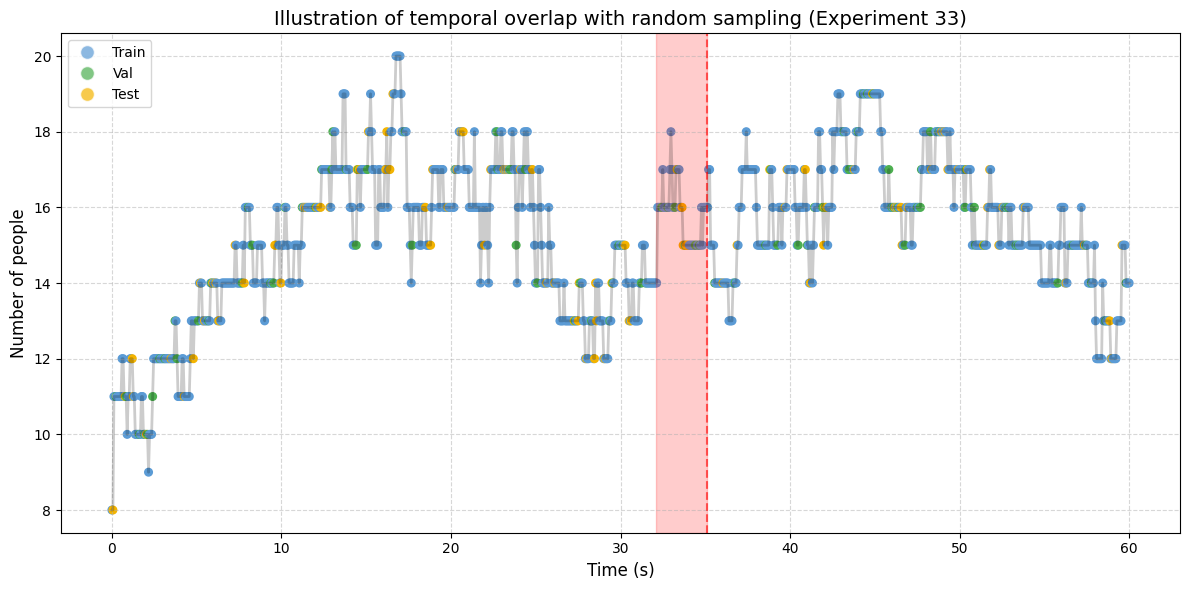

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres
groups_size = 1000
duration_sec = 60
time = np.linspace(0, duration_sec, groups_size)

# Chargement des labels
labels = data_loader.get_labels()

# Sélection de l'expérience 33
exp_id = 32
group_start = exp_id * groups_size
group_end = group_start + groups_size
group_labels = labels[group_start:group_end]

# Simuler un découpage aléatoire typique (shuffle global des indices)
indices = np.arange(groups_size)
np.random.seed(42)  # Pour reproductibilité
np.random.shuffle(indices)

# Attribution aléatoire : 80% train, 10% val, 10% test
train_indices = indices[:int(0.8 * groups_size)]
val_indices = indices[int(0.8 * groups_size):int(0.9 * groups_size)]
test_indices = indices[int(0.9 * groups_size):]

# Création d'un vecteur pour illustrer la classe (train/val/test) de chaque point dans le temps
assignment_color = np.full(groups_size, 'gray', dtype=object)
assignment_color[train_indices] = 'Train'
assignment_color[val_indices] = 'Val'
assignment_color[test_indices] = 'Test'

color_map = {
    'Train': '#5B9BD5',  # Bleu plus soutenu
    'Val':   '#4CAF50',  # Vert plus dense (type vert forêt)
    'Test':  '#F4B400'   # Jaune/orangé plus chaud et visible
}
assignment_colors = [color_map[c] for c in assignment_color]

# Tracé
plt.figure(figsize=(12, 6))
plt.plot(time, group_labels, color='black', linewidth=2, alpha= 0.2, label='People count')

# Ajout de points colorés en fond (ou en surimpression) pour illustrer l'appartenance
plt.scatter(time, group_labels, c=assignment_colors, s=30, alpha=1.0, label='Random assignment')

# Mise en forme
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Number of people', fontsize=12)
plt.title('Illustration of temporal overlap with random sampling (Experiment 33)', fontsize=14)
custom_legend = [plt.Line2D([0], [0], marker='o', color='w', label=key,
                            markerfacecolor=color_map[key], markersize=10, alpha=0.7)
                 for key in color_map]
plt.legend(handles=custom_legend, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Choisir un point d'entraînement au hasard
np.random.seed(1)  # Pour reproductibilité
random_train_idx = np.random.choice(train_indices)
random_train_time = time[random_train_idx]

# Définir une fenêtre temporelle vers l’arrière (ex: 3 secondes avant le point choisi)
leak_window = 3  # secondes
start_leak = max(0, random_train_time - leak_window)  # éviter valeurs négatives

# Afficher la zone de potentiel leakage (vers l'arrière uniquement)
plt.axvspan(start_leak, random_train_time,
            color='red', alpha=0.2, label='Zone of potential leakage')

# Marquer le point d'entraînement choisi
plt.axvline(random_train_time, color='red', linestyle='--', alpha=0.6)

plt.show()
